# **Basic setup (GPU, Installs, and Imports)**

In [3]:
# Environment setup

!pip install -q sentencepiece sacrebleu rouge-score gradio

import os
import time
import math
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict

import sentencepiece as spm
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt

import sacrebleu
from rouge_score import rouge_scorer

import gradio as gr

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# **Mount Google Drive and Unzip Dataset**

In [4]:
# Mounting Google Drive and unzip UMC005 corpus

from google.colab import drive
drive.mount('/content/drive')

DATA_ZIP_PATH = "/content/drive/MyDrive/umc005-corpus.zip"

!mkdir -p /content/umc005_corpus
!unzip -o "$DATA_ZIP_PATH" -d /content/umc005_corpus > /dev/null

print("Files in corpus folder:")
!ls -R /content/umc005_corpus

Mounted at /content/drive
Files in corpus folder:
/content/umc005_corpus:
bible  quran

/content/umc005_corpus/bible:
Bible-EN  Bible-UR-normalized  dev.ur	test.ur   train.ur
Bible-UR  dev.en	       test.en	train.en

/content/umc005_corpus/quran:
dev.en	Quran-EN  Quran-UR-normalized  test.ur	 train.ur
dev.ur	Quran-UR  test.en	       train.en


# **Load Aligned Sentence Pairs**

In [5]:
# Load aligned English–Urdu sentence pairs from BOTH Bible and Quran

def load_parallel_file(en_path: str, ur_path: str) -> List[Tuple[str, str]]:
    """
    Load a parallel corpus where each line in the English file aligns with the
    line of the same index in the Urdu file.
    """
    with open(en_path, "r", encoding="utf-8") as f_en, \
         open(ur_path, "r", encoding="utf-8") as f_ur:
        en_lines = [l.strip() for l in f_en]
        ur_lines = [l.strip() for l in f_ur]

    assert len(en_lines) == len(ur_lines), "Files must have the same number of lines."
    pairs = [(e, u) for e, u in zip(en_lines, ur_lines) if e and u]
    return pairs

# ---- Bible paths ----
BIBLE_TRAIN_EN = "/content/umc005_corpus/bible/train.en"
BIBLE_TRAIN_UR = "/content/umc005_corpus/bible/train.ur"
BIBLE_DEV_EN   = "/content/umc005_corpus/bible/dev.en"
BIBLE_DEV_UR   = "/content/umc005_corpus/bible/dev.ur"
BIBLE_TEST_EN  = "/content/umc005_corpus/bible/test.en"
BIBLE_TEST_UR  = "/content/umc005_corpus/bible/test.ur"

# ---- Quran paths ----
QURAN_TRAIN_EN = "/content/umc005_corpus/quran/train.en"
QURAN_TRAIN_UR = "/content/umc005_corpus/quran/train.ur"
QURAN_DEV_EN   = "/content/umc005_corpus/quran/dev.en"
QURAN_DEV_UR   = "/content/umc005_corpus/quran/dev.ur"
QURAN_TEST_EN  = "/content/umc005_corpus/quran/test.en"
QURAN_TEST_UR  = "/content/umc005_corpus/quran/test.ur"

# ---- Load each subset separately ----
bible_train_pairs = load_parallel_file(BIBLE_TRAIN_EN, BIBLE_TRAIN_UR)
bible_dev_pairs   = load_parallel_file(BIBLE_DEV_EN,   BIBLE_DEV_UR)
bible_test_pairs  = load_parallel_file(BIBLE_TEST_EN,  BIBLE_TEST_UR)

quran_train_pairs = load_parallel_file(QURAN_TRAIN_EN, QURAN_TRAIN_UR)
quran_dev_pairs   = load_parallel_file(QURAN_DEV_EN,   QURAN_DEV_UR)
quran_test_pairs  = load_parallel_file(QURAN_TEST_EN,  QURAN_TEST_UR)

# ---- Combine Bible + Quran ----
train_pairs = bible_train_pairs + quran_train_pairs
dev_pairs   = bible_dev_pairs   + quran_dev_pairs
test_pairs  = bible_test_pairs  + quran_test_pairs

# Shuffle to mix domains
random.shuffle(train_pairs)
random.shuffle(dev_pairs)
random.shuffle(test_pairs)

print(f"Train pairs (Bible + Quran): {len(train_pairs)}")
print(f"Dev pairs   (Bible + Quran): {len(dev_pairs)}")
print(f"Test pairs  (Bible + Quran): {len(test_pairs)}")

# Quick sanity check
for i in range(3):
    print("EN:", train_pairs[i][0])
    print("UR:", train_pairs[i][1])
    print("---")

Train pairs (Bible + Quran): 13400
Dev pairs   (Bible + Quran): 514
Test pairs  (Bible + Quran): 457
EN: And those who disbelieve are the allies of one another . ( O Muslims ! ) If you do not extend ( to one another ) the same ( help and cooperation for the cause of Allah ) , then great mischief and disruption ( for the dominance of infidelity and falsehood ) will break out in the land .
UR: اور جو لوگ کافر ہیں وہ ایک دوسرے کے مددگار ہیں ، اے مسلمانو ! اگر تم ایک دوسرے کے ساتھ ایسا تعاون اور مدد و نصرت نہیں کرو گے تو زمین میں غلبۂ کفر و باطل کا فتنہ اور بڑا فساد بپا ہو جائے گا ۔
---
EN: And Jesus rebuked him , saying , Hold thy peace , and come out of him .
UR: یسوع نے اسے جھڑک کر کہا چپ رہ اور اس میں سے نکل جا ۔
---
EN: But when ye sin so against the brethren , and wound their weak conscience , ye sin against Christ .
UR: اور تم اس طرح بھائیوں کے گنہگار ہوکر اور ان کے کمزور دل کو گھایل کرکے مسیح کے گنہگار ٹھہرتے ہو ۔
---


# **Train BPE tokenizers with SentencePiece**

In [6]:
# Train SentencePiece BPE tokenizers for English and Urdu

SP_MODEL_DIR = "/content/sp_models"
os.makedirs(SP_MODEL_DIR, exist_ok=True)

EN_SP_MODEL_PREFIX = os.path.join(SP_MODEL_DIR, "sp_en")
UR_SP_MODEL_PREFIX = os.path.join(SP_MODEL_DIR, "sp_ur")

def write_temp_corpus(pairs: List[Tuple[str, str]], idx: int, lang: str) -> str:
    """
    Write a temporary plain-text corpus for one language for tokenizer training.
    """
    path = f"/content/tmp_{lang}_{idx}.txt"
    with open(path, "w", encoding="utf-8") as f:
        for src, tgt in pairs:
            if lang == "en":
                f.write(src + "\n")
            else:
                f.write(tgt + "\n")
    return path

# Combine train + dev for tokenization
all_train_dev_pairs = train_pairs + dev_pairs

tmp_en = write_temp_corpus(all_train_dev_pairs, 0, "en")
tmp_ur = write_temp_corpus(all_train_dev_pairs, 0, "ur")

# Vocabulary sizes (you can tune)
EN_VOCAB_SIZE = 8000
UR_VOCAB_SIZE = 8000

spm.SentencePieceTrainer.Train(
    input=tmp_en,
    model_prefix=EN_SP_MODEL_PREFIX,
    vocab_size=EN_VOCAB_SIZE,
    character_coverage=1.0,
    model_type="bpe",
    bos_id=-1, eos_id=-1, pad_id=-1, unk_id=0
)

spm.SentencePieceTrainer.Train(
    input=tmp_ur,
    model_prefix=UR_SP_MODEL_PREFIX,
    vocab_size=UR_VOCAB_SIZE,
    character_coverage=1.0,
    model_type="bpe",
    bos_id=-1, eos_id=-1, pad_id=-1, unk_id=0
)

print("Tokenizer models saved in:", SP_MODEL_DIR)

Tokenizer models saved in: /content/sp_models


# **Wrap Tokenizers, add Special Tokens**

In [7]:
# Load tokenizers and define helper functions

sp_en = spm.SentencePieceProcessor()
sp_en.Load(f"{EN_SP_MODEL_PREFIX}.model")

sp_ur = spm.SentencePieceProcessor()
sp_ur.Load(f"{UR_SP_MODEL_PREFIX}.model")

# We reserve IDs for special tokens and shift SentencePiece output by +3
PAD_ID = 0
BOS_ID = 1
EOS_ID = 2

def encode_en(text: str, max_len: int = 64) -> List[int]:
    """
    Encode English text into token ids with BOS/EOS and padding.
    """
    ids = sp_en.EncodeAsIds(text)
    ids = [BOS_ID] + [i + 3 for i in ids][: max_len - 2] + [EOS_ID]
    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))
    return ids

def encode_ur(text: str, max_len: int = 64) -> List[int]:
    """
    Encode Urdu text into token ids with BOS/EOS and padding.
    """
    ids = sp_ur.EncodeAsIds(text)
    ids = [BOS_ID] + [i + 3 for i in ids][: max_len - 2] + [EOS_ID]
    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))
    return ids

def decode_en(ids: List[int]) -> str:
    """
    Decode English token ids back to text (ignoring padding and special tokens).
    """
    ids = [i - 3 for i in ids if i >= 3 and i not in (PAD_ID, BOS_ID, EOS_ID)]
    return sp_en.DecodeIds(ids)

def decode_ur(ids: List[int]) -> str:
    """
    Decode Urdu token ids back to text (ignoring padding and special tokens).
    """
    ids = [i - 3 for i in ids if i >= 3 and i not in (PAD_ID, BOS_ID, EOS_ID)]
    return sp_ur.DecodeIds(ids)

EN_VOCAB_TOTAL = sp_en.GetPieceSize() + 3
UR_VOCAB_TOTAL = sp_ur.GetPieceSize() + 3

print("EN vocab size (with specials):", EN_VOCAB_TOTAL)
print("UR vocab size (with specials):", UR_VOCAB_TOTAL)

EN vocab size (with specials): 8003
UR vocab size (with specials): 8003


# **Dataset + DataLoader**

In [8]:
# PyTorch Dataset and DataLoader

MAX_SRC_LEN = 64
MAX_TGT_LEN = 64

class TranslationDataset(Dataset):
    """
    Simple dataset for parallel English–Urdu sentences.
    Returns encoder input, decoder input, and decoder target.
    """
    def __init__(self, pairs: List[Tuple[str, str]]):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = encode_en(src, max_len=MAX_SRC_LEN)
        tgt_ids = encode_ur(tgt, max_len=MAX_TGT_LEN)

        # Decoder input is shifted right (no last token)
        dec_in = tgt_ids[:-1]
        # Decoder target is shifted left (no first token)
        dec_tgt = tgt_ids[1:]
        return torch.tensor(src_ids), torch.tensor(dec_in), torch.tensor(dec_tgt)

BATCH_SIZE = 64

train_dataset = TranslationDataset(train_pairs)
dev_dataset   = TranslationDataset(dev_pairs)
test_dataset  = TranslationDataset(test_pairs)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

len(train_loader), len(dev_loader), len(test_loader)

(210, 9, 8)

# **Positional Encoding + MultiHeadAttention Blocks**

In [9]:
# Transformer building blocks

class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding, added to token embeddings.
    """
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # [1, max_len, d_model]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        length = x.size(1)
        return x + self.pe[:, :length].to(x.device)


class MultiHeadAttention(nn.Module):
    """
    Standard multi-head attention module with separate Q, K, V projections.
    Shapes:
      - query: [B, Q_len, d_model]
      - key:   [B, K_len, d_model]
      - value: [B, K_len, d_model]
    Output:
      - [B, Q_len, d_model]
    """
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _shape(self, x, batch_size):
        """
        Projected tensor x is [B, L, d_model]; reshape to [B, heads, L, d_k].
        """
        B, L, _ = x.size()
        x = x.view(B, L, self.num_heads, self.d_k)   # [B, L, H, d_k]
        x = x.transpose(1, 2)                        # [B, H, L, d_k]
        return x

    def forward(self, query, key, value, mask=None, need_weights=False):
        B, Q_len, _ = query.size()
        Bk, K_len, _ = key.size()

        # Linear projections
        Q = self.q_linear(query)   # [B, Q_len, d_model]
        K = self.k_linear(key)     # [B, K_len, d_model]
        V = self.v_linear(value)   # [B, K_len, d_model]

        # Reshape for multi-head: [B, H, L, d_k]
        Q = self._shape(Q, B)
        K = self._shape(K, Bk)
        V = self._shape(V, Bk)

        # Attention scores: [B, H, Q_len, K_len]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            # mask expected [B, 1, 1 or Q_len, K_len] or broadcastable
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        # Context: [B, H, Q_len, d_k]
        context = torch.matmul(attn, V)

        # -> [B, Q_len, H, d_k]
        context = context.transpose(1, 2).contiguous()

        # Merge heads: d_model = H * d_k
        Bc, Qc, H, d_k = context.size()
        context = context.view(Bc, Qc, H * d_k)      # [B, Q_len, d_model]

        output = self.out_proj(context)

        if need_weights:
            return output, attn
        return output

# **Encoder/Decoder layers and full Transformer**

In [10]:
# Encoder, Decoder, and full Transformer model

class FeedForward(nn.Module):
    """
    Position-wise feed-forward network used in Transformer blocks.
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x


class EncoderLayer(nn.Module):
    """
    Single Transformer encoder layer with self-attention and feed-forward.
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        attn_out = self.self_attn(src, src, src, src_mask)
        src = self.norm1(src + self.dropout(attn_out))
        ff_out = self.ff(src)
        src = self.norm2(src + self.dropout(ff_out))
        return src


class DecoderLayer(nn.Module):
    """
    Single Transformer decoder layer with masked self-attention,
    encoder-decoder attention, and feed-forward.
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.enc_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask, memory_mask, need_attn_weights=False):
        self_attn_out = self.self_attn(tgt, tgt, tgt, tgt_mask)
        tgt = self.norm1(tgt + self.dropout(self_attn_out))

        if need_attn_weights:
            enc_attn_out, attn_weights = self.enc_attn(
                tgt, memory, memory, memory_mask, need_weights=True
            )
        else:
            enc_attn_out = self.enc_attn(tgt, memory, memory, memory_mask)
            attn_weights = None

        tgt = self.norm2(tgt + self.dropout(enc_attn_out))
        ff_out = self.ff(tgt)
        tgt = self.norm3(tgt + self.dropout(ff_out))
        return tgt, attn_weights


class Encoder(nn.Module):
    """
    Stacked Transformer encoder.
    """
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = PositionalEncoding(d_model, max_len=MAX_SRC_LEN)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

    def forward(self, src, src_mask):
        x = self.embed(src) * math.sqrt(self.embed.embedding_dim)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, src_mask)
        return x


class Decoder(nn.Module):
    """
    Stacked Transformer decoder.
    """
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = PositionalEncoding(d_model, max_len=MAX_TGT_LEN)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, tgt, memory, tgt_mask, memory_mask, need_last_attn=False):
        x = self.embed(tgt) * math.sqrt(self.embed.embedding_dim)
        x = self.pos_enc(x)
        last_attn = None
        for i, layer in enumerate(self.layers):
            need_weights = need_last_attn and (i == len(self.layers) - 1)
            x, attn_weights = layer(x, memory, tgt_mask, memory_mask, need_attn_weights=need_weights)
            if need_weights:
                last_attn = attn_weights
        logits = self.fc_out(x)
        return logits, last_attn


class TransformerMT(nn.Module):
    """
    Full encoder-decoder Transformer for machine translation with
    helper methods for masks and greedy decoding.
    """
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=256,
        num_layers=3,
        num_heads=8,
        d_ff=512,
        dropout=0.1,
    ):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, dropout)

    def make_src_mask(self, src):
        return (src != PAD_ID).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        batch_size, seq_len = tgt.size()
        pad_mask = (tgt != PAD_ID).unsqueeze(1).unsqueeze(2)
        subsequent_mask = torch.tril(torch.ones((1, 1, seq_len, seq_len), device=tgt.device))
        return pad_mask & subsequent_mask.bool()

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        memory = self.encoder(src, src_mask)
        logits, _ = self.decoder(tgt, memory, tgt_mask, src_mask)
        return logits

    def greedy_decode(self, src, max_len=MAX_TGT_LEN):
        self.eval()
        with torch.no_grad():
            src_mask = self.make_src_mask(src)
            memory = self.encoder(src, src_mask)
            batch_size = src.size(0)
            ys = torch.full((batch_size, 1), BOS_ID, dtype=torch.long, device=src.device)

            for _ in range(max_len - 1):
                tgt_mask = self.make_tgt_mask(ys)
                logits, _ = self.decoder(ys, memory, tgt_mask, src_mask)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                ys = torch.cat([ys, next_token], dim=1)
            return ys

    def greedy_decode_with_attention(self, src, max_len=MAX_TGT_LEN):
        """
        Same as greedy_decode but returns attention from the last decoder layer
        for visualization.
        """
        self.eval()
        with torch.no_grad():
            src_mask = self.make_src_mask(src)
            memory = self.encoder(src, src_mask)
            batch_size = src.size(0)
            ys = torch.full((batch_size, 1), BOS_ID, dtype=torch.long, device=src.device)
            last_attn = None
            for _ in range(max_len - 1):
                tgt_mask = self.make_tgt_mask(ys)
                logits, attn = self.decoder(ys, memory, tgt_mask, src_mask, need_last_attn=True)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                ys = torch.cat([ys, next_token], dim=1)
                last_attn = attn
            return ys, last_attn

# **Instantiate Transformer, Optimizer, Scheduler, Early Stopping Config**

In [11]:
# Instantiate Transformer model and training utilities

transformer = TransformerMT(
    src_vocab_size=EN_VOCAB_TOTAL,
    tgt_vocab_size=UR_VOCAB_TOTAL,
    d_model=256,
    num_layers=3,
    num_heads=8,
    d_ff=512,
    dropout=0.1,
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = torch.optim.Adam(transformer.parameters(), lr=3e-4, betas=(0.9, 0.98), eps=1e-9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.7)

NUM_EPOCHS = 15
PATIENCE = 3  # early stopping
best_dev_loss = float("inf")
patience_counter = 0

train_losses = []
dev_losses = []

def compute_perplexity(loss_value: float) -> float:
    """
    Convert cross-entropy loss to perplexity.
    """
    try:
        return math.exp(loss_value)
    except OverflowError:
        return float("inf")

# **Transformer Training Loop**

In [12]:
# Training loop for Transformer

def run_epoch(model, data_loader, train_mode: bool = True):
    """
    Run one training or validation epoch and return average loss and duration.
    """
    start_time = time.time()
    total_loss = 0.0
    total_tokens = 0

    if train_mode:
        model.train()
    else:
        model.eval()

    for src, dec_in, dec_tgt in data_loader:
        src = src.to(device)
        dec_in = dec_in.to(device)
        dec_tgt = dec_tgt.to(device)

        if train_mode:
            optimizer.zero_grad()

        logits = model(src, dec_in)
        vocab_size = logits.size(-1)
        loss = criterion(logits.view(-1, vocab_size), dec_tgt.view(-1))

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        num_tokens = (dec_tgt != PAD_ID).sum().item()
        total_loss += loss.item() * num_tokens
        total_tokens += num_tokens

    avg_loss = total_loss / max(1, total_tokens)
    duration = time.time() - start_time
    return avg_loss, duration

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_time = run_epoch(transformer, train_loader, train_mode=True)
    dev_loss, dev_time = run_epoch(transformer, dev_loader, train_mode=False)

    train_losses.append(train_loss)
    dev_losses.append(dev_loss)
    scheduler.step()

    train_ppl = compute_perplexity(train_loss)
    dev_ppl = compute_perplexity(dev_loss)

    print(f"Epoch {epoch:02d}: "
          f"train_loss={train_loss:.4f} (ppl={train_ppl:.2f}, {train_time:.1f}s), "
          f"dev_loss={dev_loss:.4f} (ppl={dev_ppl:.2f}, {dev_time:.1f}s)")

    if dev_loss < best_dev_loss:
        best_dev_loss = dev_loss
        patience_counter = 0
        torch.save(transformer.state_dict(), "/content/best_transformer.pt")
        print("  -> New best model saved.")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

print("Transformer training complete.")

Epoch 01: train_loss=5.7711 (ppl=320.88, 30.8s), dev_loss=5.0538 (ppl=156.62, 0.4s)
  -> New best model saved.
Epoch 02: train_loss=4.7178 (ppl=111.92, 16.5s), dev_loss=4.6842 (ppl=108.23, 0.2s)
  -> New best model saved.
Epoch 03: train_loss=4.3351 (ppl=76.33, 16.5s), dev_loss=4.5038 (ppl=90.36, 0.3s)
  -> New best model saved.
Epoch 04: train_loss=4.0762 (ppl=58.92, 17.3s), dev_loss=4.3609 (ppl=78.33, 0.3s)
  -> New best model saved.
Epoch 05: train_loss=3.8679 (ppl=47.84, 17.2s), dev_loss=4.2828 (ppl=72.44, 0.3s)
  -> New best model saved.
Epoch 06: train_loss=3.6763 (ppl=39.50, 22.0s), dev_loss=4.2319 (ppl=68.85, 0.3s)
  -> New best model saved.
Epoch 07: train_loss=3.5472 (ppl=34.72, 17.0s), dev_loss=4.2013 (ppl=66.77, 0.3s)
  -> New best model saved.
Epoch 08: train_loss=3.4321 (ppl=30.94, 17.1s), dev_loss=4.1593 (ppl=64.02, 0.3s)
  -> New best model saved.
Epoch 09: train_loss=3.3242 (ppl=27.78, 17.2s), dev_loss=4.1445 (ppl=63.09, 0.3s)
  -> New best model saved.
Epoch 10: train

# **Transformer Loss Curves (training/validation)**

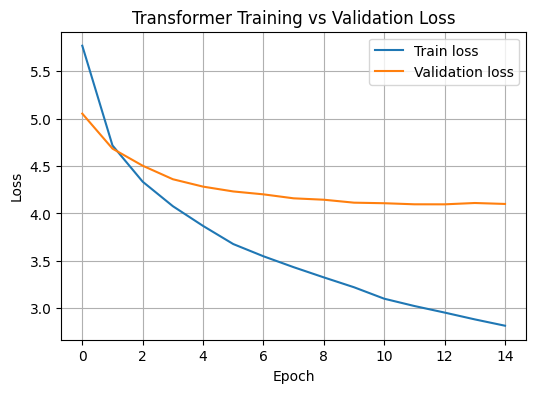

In [13]:
# Transformer Plot training and validation loss

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(dev_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig('transformer_loss_plot.png', dpi=300)
plt.show()

# **Evaluation Helpers (BLEU, ROUGE, Sample translations, Timing, Memory)**

In [14]:
# Evaluation utilities for translation quality and resource usage

def translate_batch(model, src_batch: List[str]) -> List[str]:
    """
    Translate a list of English sentences using greedy decoding.
    """
    model.eval()
    with torch.no_grad():
        src_ids = [encode_en(s, max_len=MAX_SRC_LEN) for s in src_batch]
        src_tensor = torch.tensor(src_ids, dtype=torch.long, device=device)
        out_ids = model.greedy_decode(src_tensor, max_len=MAX_TGT_LEN)
        outputs = [decode_ur(seq.tolist()) for seq in out_ids]
    return outputs

def evaluate_bleu_rouge(model, data_loader, max_batches: int = 50):
    """
    Compute BLEU and ROUGE-L on a subset of the dataset for speed.
    """
    model.eval()
    refs = []
    hyps = []
    batch_count = 0

    for src, _, dec_tgt in data_loader:
        src_texts = [decode_en(ids.tolist()) for ids in src]
        tgt_texts = [decode_ur(row.tolist()) for row in dec_tgt]  # approximate reference

        preds = translate_batch(model, src_texts)

        hyps.extend(preds)
        refs.extend([[t] for t in tgt_texts])

        batch_count += 1
        if batch_count >= max_batches:
            break

    bleu = sacrebleu.corpus_bleu(hyps, refs)
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    rouge_scores = [scorer.score(r[0], h)['rougeL'].fmeasure for h, r in zip(hyps, refs)]
    rouge_l = sum(rouge_scores) / len(rouge_scores)

    return bleu.score, rouge_l

def benchmark_inference(model, num_sentences: int = 100):
    """
    Rough benchmark of inference speed and GPU memory.
    """
    sample_pairs = random.sample(test_pairs, min(num_sentences, len(test_pairs)))
    src_texts = [p[0] for p in sample_pairs]

    torch.cuda.empty_cache()
    if device.type == "cuda":
        before_mem = torch.cuda.memory_allocated(device)
    else:
        before_mem = 0

    start = time.time()
    _ = translate_batch(model, src_texts)
    duration = time.time() - start

    if device.type == "cuda":
        after_mem = torch.cuda.memory_allocated(device)
        mem_used_mb = (after_mem - before_mem) / (1024**2)
    else:
        mem_used_mb = 0

    return duration, mem_used_mb

# **Load best Transformer, Compute Metrics, Show Examples**

In [15]:
# Final evaluation of Transformer

transformer.load_state_dict(torch.load("/content/best_transformer.pt", map_location=device))

bleu_score, rouge_l = evaluate_bleu_rouge(transformer, test_loader, max_batches=50)
test_loss, test_time = run_epoch(transformer, test_loader, train_mode=False)
test_ppl = compute_perplexity(test_loss)
inf_time, mem_used = benchmark_inference(transformer, num_sentences=200)

print(f"Transformer Test Loss: {test_loss:.4f}, Perplexity: {test_ppl:.2f}")
print(f"Transformer BLEU: {bleu_score:.2f}")
print(f"Transformer ROUGE-L (F1): {rouge_l:.4f}")
print(f"Inference time for 200 sentences: {inf_time:.2f} s")
print(f"Approx. extra GPU memory used: {mem_used:.2f} MB")

# Show some example translations
sample_pairs = random.sample(test_pairs, 5)
src_texts = [p[0] for p in sample_pairs]
tgt_texts = [p[1] for p in sample_pairs]
preds = translate_batch(transformer, src_texts)

for en, ur_true, ur_pred in zip(src_texts, tgt_texts, preds):
    print("EN:", en)
    print("UR (gold):", ur_true)
    print("UR (pred):", ur_pred)
    print("-" * 40)

Transformer Test Loss: 4.5202, Perplexity: 91.85
Transformer BLEU: 11.14
Transformer ROUGE-L (F1): 0.0000
Inference time for 200 sentences: 1.71 s
Approx. extra GPU memory used: 0.00 MB
EN: Indeed it is binding on Us to show you the path ( of Truth ) .
UR (gold): بیشک راہ حق دکھانا ہمارے ذمہ ہے ۔
UR (pred): بیشک آپ کا حق ہے جو آپ کو حق پر ہے اسے حق پر ثابت قدم رکھتے ہیں ۔ کرنے والے ہیں ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔
----------------------------------------
EN: And shall go out to deceive the nations which are in the four quarters of the earth , Gog and Magog , to gather them together to battle : the number of whom is as the sand of the sea .
UR (gold): اور ان قوموں کو جو زمین کے چاروں طرف ہوں گی یعنی جوج و ماجوج کو گمراہ کرکے لڑائی کے لئے جمع کرنے کو نکلے گا ۔ ان کا شمار سمندر کی ریت کے برابر ہوگا ۔
UR (pred): اور زمین کو جو زمین میں ہیں ان کے لئے زمین کی مانند ہے ۔ وہ جو زمین میں ہیں اور جو زمین میں ہیں ۔ ہیں ۔ کی راہ سے نکالتا ہے ۔ ہے ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔
--------------

# **LSTM baseline Model (Seq2Seq with Attention)**

In [16]:
# LSTM baseline model with attention (fixed shapes)

class LSTMEncoder(nn.Module):
    """
    Unidirectional LSTM encoder for source sentences.
    Output shape:
      - enc_outputs: [B, src_len, hidden_size]
      - h, c: [num_layers, B, hidden_size]
    """
    def __init__(self, vocab_size, d_model, hidden_size, num_layers=1, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, src, src_lengths=None):
        x = self.embed(src)
        outputs, (h, c) = self.lstm(x)
        return outputs, (h, c)


class Attention(nn.Module):
    """
    Simple dot-product attention over encoder outputs.
    enc_outputs: [B, src_len, H]
    dec_hidden:  [B, H]
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.scale = 1.0 / math.sqrt(hidden_size)

    def forward(self, dec_hidden, enc_outputs, mask):
        # scores: [B, src_len]
        scores = torch.bmm(enc_outputs, dec_hidden.unsqueeze(2)).squeeze(2)
        scores = scores * self.scale
        scores = scores.masked_fill(mask == 0, float("-inf"))
        attn_weights = torch.softmax(scores, dim=1)         # [B, src_len]

        # context: [B, H]
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context, attn_weights


class LSTMDecoder(nn.Module):
    """
    LSTM decoder with attention.
    Context vector has dim hidden_size (same as decoder hidden).
    """
    def __init__(self, vocab_size, d_model, hidden_size, num_layers=1, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(
            input_size=d_model + hidden_size,  # dec_input + context
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attn = Attention(hidden_size)
        self.fc_out = nn.Linear(hidden_size + hidden_size, vocab_size)

    def forward(self, tgt, enc_outputs, enc_mask, hidden=None):
        batch_size, tgt_len = tgt.shape
        embeddings = self.embed(tgt)          # [B, tgt_len, d_model]
        outputs = []
        h, c = hidden                         # [num_layers, B, H]

        for t in range(tgt_len):
            dec_input = embeddings[:, t, :]   # [B, d_model]
            dec_hidden = h[-1]               # [B, H] (last layer)
            context, _ = self.attn(dec_hidden, enc_outputs, enc_mask)  # [B, H]

            lstm_input = torch.cat([dec_input, context], dim=1).unsqueeze(1)  # [B, 1, d_model+H]
            out, (h, c) = self.lstm(lstm_input, (h, c))  # out: [B, 1, H]
            out = out.squeeze(1)                         # [B, H]

            logits = self.fc_out(torch.cat([out, context], dim=1))  # [B, vocab_size]
            outputs.append(logits)

        logits = torch.stack(outputs, dim=1)  # [B, tgt_len, vocab_size]
        return logits


class LSTMSeq2Seq(nn.Module):
    """
    Full encoder-decoder LSTM model for translation.
    """
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, hidden_size=256, num_layers=1, dropout=0.1):
        super().__init__()
        self.encoder = LSTMEncoder(src_vocab_size, d_model, hidden_size, num_layers, dropout)
        self.decoder = LSTMDecoder(tgt_vocab_size, d_model, hidden_size, num_layers, dropout)

    def forward(self, src, tgt):
        enc_outputs, (h, c) = self.encoder(src)
        enc_mask = (src != PAD_ID).int()
        logits = self.decoder(tgt, enc_outputs, enc_mask, hidden=(h, c))
        return logits

    def greedy_decode(self, src, max_len=MAX_TGT_LEN):
        """
        Simple greedy decoding for the LSTM baseline.
        """
        self.eval()
        with torch.no_grad():
            enc_outputs, (h, c) = self.encoder(src)
            enc_mask = (src != PAD_ID).int()
            batch_size = src.size(0)

            ys = torch.full((batch_size, 1), BOS_ID, dtype=torch.long, device=src.device)
            for _ in range(max_len - 1):
                logits = self.decoder(ys, enc_outputs, enc_mask, hidden=(h, c))
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                ys = torch.cat([ys, next_token], dim=1)
            return ys

# **Train LSTM Baseline**

In [17]:
# Train LSTM baseline

lstm_model = LSTMSeq2Seq(
    src_vocab_size=EN_VOCAB_TOTAL,
    tgt_vocab_size=UR_VOCAB_TOTAL,
    d_model=256,
    hidden_size=256,
    num_layers=1,
    dropout=0.1,
).to(device)

lstm_criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=3e-4)
lstm_scheduler = torch.optim.lr_scheduler.StepLR(lstm_optimizer, step_size=5, gamma=0.7)

NUM_EPOCHS_LSTM = 10
best_dev_loss_lstm = float("inf")
patience_lstm = 3
patience_counter_lstm = 0

lstm_train_losses = []
lstm_dev_losses = []

def run_epoch_lstm(model, data_loader, train_mode=True):
    """
    Run one training or validation epoch for LSTM baseline.
    """
    start_time = time.time()
    total_loss = 0.0
    total_tokens = 0

    if train_mode:
        model.train()
    else:
        model.eval()

    for src, dec_in, dec_tgt in data_loader:
        src = src.to(device)
        dec_in = dec_in.to(device)
        dec_tgt = dec_tgt.to(device)

        if train_mode:
            lstm_optimizer.zero_grad()

        logits = model(src, dec_in)
        vocab_size = logits.size(-1)
        loss = lstm_criterion(logits.view(-1, vocab_size), dec_tgt.view(-1))

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            lstm_optimizer.step()

        num_tokens = (dec_tgt != PAD_ID).sum().item()
        total_loss += loss.item() * num_tokens
        total_tokens += num_tokens

    avg_loss = total_loss / max(1, total_tokens)
    duration = time.time() - start_time
    return avg_loss, duration

for epoch in range(1, NUM_EPOCHS_LSTM + 1):
    train_loss, train_time = run_epoch_lstm(lstm_model, train_loader, train_mode=True)
    dev_loss, dev_time = run_epoch_lstm(lstm_model, dev_loader, train_mode=False)

    lstm_train_losses.append(train_loss)
    lstm_dev_losses.append(dev_loss)
    lstm_scheduler.step()

    train_ppl = compute_perplexity(train_loss)
    dev_ppl = compute_perplexity(dev_loss)

    print(f"[LSTM] Epoch {epoch:02d}: "
          f"train_loss={train_loss:.4f} (ppl={train_ppl:.2f}, {train_time:.1f}s), "
          f"dev_loss={dev_loss:.4f} (ppl={dev_ppl:.2f}, {dev_time:.1f}s)")

    if dev_loss < best_dev_loss_lstm:
        best_dev_loss_lstm = dev_loss
        patience_counter_lstm = 0
        torch.save(lstm_model.state_dict(), "/content/best_lstm.pt")
        print("  -> New best LSTM model saved.")
    else:
        patience_counter_lstm += 1
        if patience_counter_lstm >= patience_lstm:
            print("LSTM early stopping triggered.")
            break

print("LSTM training complete.")

[LSTM] Epoch 01: train_loss=6.2530 (ppl=519.58, 28.6s), dev_loss=5.5957 (ppl=269.26, 0.4s)
  -> New best LSTM model saved.
[LSTM] Epoch 02: train_loss=5.3435 (ppl=209.25, 28.6s), dev_loss=5.1936 (ppl=180.11, 0.4s)
  -> New best LSTM model saved.
[LSTM] Epoch 03: train_loss=4.9498 (ppl=141.15, 29.0s), dev_loss=4.9530 (ppl=141.59, 0.6s)
  -> New best LSTM model saved.
[LSTM] Epoch 04: train_loss=4.6824 (ppl=108.03, 28.8s), dev_loss=4.7873 (ppl=119.97, 0.4s)
  -> New best LSTM model saved.
[LSTM] Epoch 05: train_loss=4.4755 (ppl=87.84, 28.6s), dev_loss=4.6661 (ppl=106.28, 0.4s)
  -> New best LSTM model saved.
[LSTM] Epoch 06: train_loss=4.3091 (ppl=74.38, 28.5s), dev_loss=4.5862 (ppl=98.12, 0.4s)
  -> New best LSTM model saved.
[LSTM] Epoch 07: train_loss=4.1948 (ppl=66.34, 29.5s), dev_loss=4.5278 (ppl=92.56, 0.4s)
  -> New best LSTM model saved.
[LSTM] Epoch 08: train_loss=4.0905 (ppl=59.77, 28.5s), dev_loss=4.4788 (ppl=88.13, 0.6s)
  -> New best LSTM model saved.
[LSTM] Epoch 09: train_

# **LSTM Loss Curves (training/validation)**

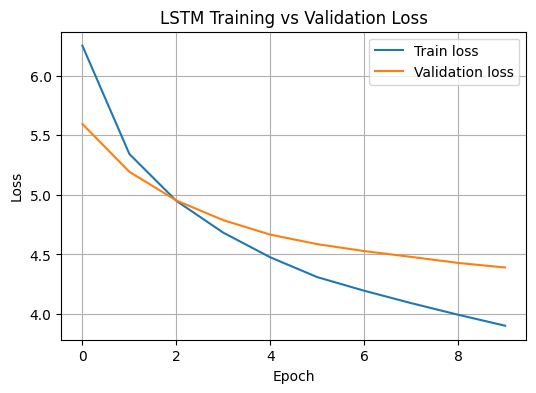

In [18]:
# LSTM Plot training and validation loss

plt.figure(figsize=(6, 4))
plt.plot(lstm_train_losses, label="Train loss")
plt.plot(lstm_dev_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig('lstm_loss_plot.png', dpi=300)
plt.show()

# **Compare Transformer vs LSTM**

In [19]:
# Comparative analysis metrics

def translate_batch_lstm(model, src_batch: List[str]) -> List[str]:
    model.eval()
    with torch.no_grad():
        src_ids = [encode_en(s, max_len=MAX_SRC_LEN) for s in src_batch]
        src_tensor = torch.tensor(src_ids, dtype=torch.long, device=device)
        out_ids = model.greedy_decode(src_tensor, max_len=MAX_TGT_LEN)
        outputs = [decode_ur(seq.tolist()) for seq in out_ids]
    return outputs

def evaluate_bleu_rouge_lstm(model, data_loader, max_batches: int = 50):
    model.eval()
    refs = []
    hyps = []
    batch_count = 0

    for src, _, dec_tgt in data_loader:
        src_texts = [decode_en(ids.tolist()) for ids in src]
        tgt_texts = [decode_ur(row.tolist()) for row in dec_tgt]

        preds = translate_batch_lstm(model, src_texts)

        hyps.extend(preds)
        refs.extend([[t] for t in tgt_texts])

        batch_count += 1
        if batch_count >= max_batches:
            break

    bleu = sacrebleu.corpus_bleu(hyps, refs)
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    rouge_scores = [scorer.score(r[0], h)['rougeL'].fmeasure for h, r in zip(hyps, refs)]
    rouge_l = sum(rouge_scores) / len(rouge_scores)
    return bleu.score, rouge_l

def benchmark_inference_lstm(model, num_sentences: int = 100):
    sample_pairs = random.sample(test_pairs, min(num_sentences, len(test_pairs)))
    src_texts = [p[0] for p in sample_pairs]

    torch.cuda.empty_cache()
    if device.type == "cuda":
        before_mem = torch.cuda.memory_allocated(device)
    else:
        before_mem = 0

    start = time.time()
    _ = translate_batch_lstm(model, src_texts)
    duration = time.time() - start

    if device.type == "cuda":
        after_mem = torch.cuda.memory_allocated(device)
        mem_used_mb = (after_mem - before_mem) / (1024**2)
    else:
        mem_used_mb = 0

    return duration, mem_used_mb

# Load best LSTM
lstm_model.load_state_dict(torch.load("/content/best_lstm.pt", map_location=device))

# Metrics
lstm_bleu, lstm_rouge = evaluate_bleu_rouge_lstm(lstm_model, test_loader, max_batches=50)
lstm_test_loss, lstm_test_time = run_epoch_lstm(lstm_model, test_loader, train_mode=False)
lstm_test_ppl = compute_perplexity(lstm_test_loss)
lstm_inf_time, lstm_mem_used = benchmark_inference_lstm(lstm_model, num_sentences=200)

print("=== Transformer vs LSTM Comparison ===")
print(f"Transformer - Loss: {test_loss:.4f}, PPL: {test_ppl:.2f}, BLEU: {bleu_score:.2f}, "
      f"ROUGE-L: {rouge_l:.4f}, Inf time: {inf_time:.2f}s, Mem: {mem_used:.2f}MB")

print(f"LSTM        - Loss: {lstm_test_loss:.4f}, PPL: {lstm_test_ppl:.2f}, BLEU: {lstm_bleu:.2f}, "
      f"ROUGE-L: {lstm_rouge:.4f}, Inf time: {lstm_inf_time:.2f}s, Mem: {lstm_mem_used:.2f}MB")

=== Transformer vs LSTM Comparison ===
Transformer - Loss: 4.5202, PPL: 91.85, BLEU: 11.14, ROUGE-L: 0.0000, Inf time: 1.71s, Mem: 0.00MB
LSTM        - Loss: 4.7824, PPL: 119.39, BLEU: 9.75, ROUGE-L: 0.0000, Inf time: 2.15s, Mem: 0.00MB


# **Simple ChatGPT- Style GUI (Gradio)**

In [20]:
# Gradio chat-style UI for English -> Urdu translation (Transformer)

def chat_translate(history, user_input):
    """
    Handle one chat turn: take user English input and append model's Urdu translation.
    """
    if user_input.strip() == "":
        return history

    model = transformer
    en_text = user_input.strip()
    ur_text = translate_batch(model, [en_text])[0]

    # The user message (left-aligned) and model reply (simulated right-aligned)
    history = history + [[f"EN: {en_text}", f"UR: {ur_text}"]]
    return history

with gr.Blocks() as demo:
    gr.Markdown("# English → Urdu Translator (Transformer)\nChat-style interface like ChatGPT.")
    chatbot = gr.Chatbot(label="Chat History")
    msg = gr.Textbox(label="Type English text and press Enter")
    clear = gr.Button("Clear")

    msg.submit(chat_translate, [chatbot, msg], chatbot)
    msg.submit(lambda: "", [], msg)
    clear.click(lambda: [], None, chatbot)

demo.launch(share=False)

/tmp/ipython-input-3845520798.py:20: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(label="Chat History")
/tmp/ipython-input-3845520798.py:20: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(label="Chat History")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

# **Attention Visualization**

Example EN: Nor is there anyone equal to Him .


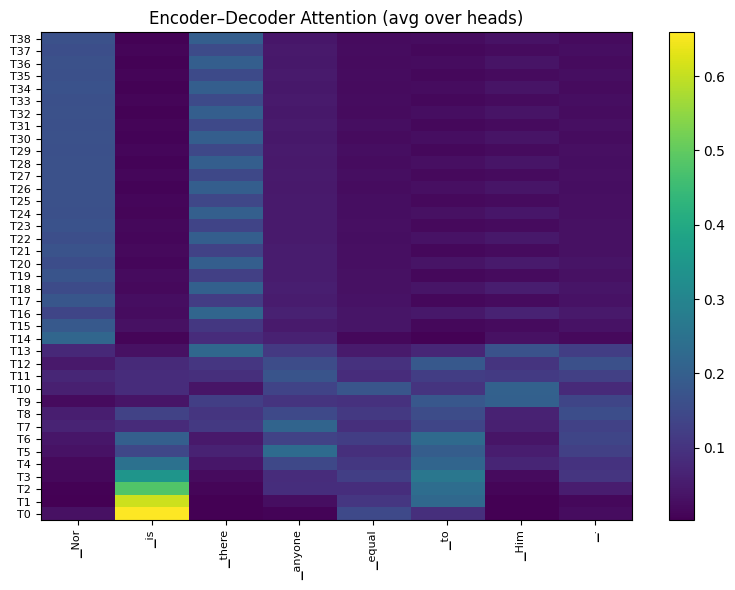

Target index -> Urdu subword
T0: ▁اور
T1: ▁نہ
T2: ▁کوئی
T3: ▁اور
T4: ▁نہ
T5: ▁کوئی
T6: ▁شک
T7: ▁وہ
T8: ▁اس
T9: ▁کے
T10: ▁سوا
T11: ▁کوئی
T12: ▁معبود
T13: ▁ہے
T14: ▁۔
T15: ▁۔
T16: ▁۔
T17: ▁۔
T18: ▁۔
T19: ▁۔
T20: ▁۔
T21: ▁۔
T22: ▁۔
T23: ▁۔
T24: ▁۔
T25: ▁۔
T26: ▁۔
T27: ▁۔
T28: ▁۔
T29: ▁۔
T30: ▁۔
T31: ▁۔
T32: ▁۔
T33: ▁۔
T34: ▁۔
T35: ▁۔
T36: ▁۔
T37: ▁۔
T38: ▁۔


In [21]:
# Attention visualization for a single example (font-safe)

def visualize_attention(en_sentence: str):
    """
    Visualize which English tokens the Transformer attends to when producing Urdu tokens.
    Uses English tokens on x-axis and target indices on y-axis,
    and prints Urdu tokens separately to avoid Arabic font issues.
    """
    transformer.eval()
    with torch.no_grad():
        src_ids = torch.tensor([encode_en(en_sentence, max_len=MAX_SRC_LEN)], device=device)
        out_ids, attn = transformer.greedy_decode_with_attention(src_ids, max_len=MAX_TGT_LEN)

    src_tokens_ids = src_ids[0].tolist()
    tgt_tokens_ids = out_ids[0].tolist()

    # English tokens (safe to display on axis)
    src_tokens = [sp_en.IdToPiece(i - 3)
                  for i in src_tokens_ids
                  if i >= 3 and i not in (BOS_ID, EOS_ID, PAD_ID)]

    # Urdu tokens (we will just print them)
    tgt_tokens = [sp_ur.IdToPiece(i - 3)
                  for i in tgt_tokens_ids
                  if i >= 3 and i not in (BOS_ID, EOS_ID, PAD_ID)]

    if attn is None:
        print("No attention weights captured.")
        return

    # attn: [batch, heads, tgt_len, src_len]
    attn = attn[0].mean(dim=0).cpu().numpy()  # average over heads

    tgt_len = min(len(tgt_tokens), attn.shape[0])
    src_len = min(len(src_tokens), attn.shape[1])
    attn = attn[:tgt_len, :src_len]

    # Make sure plots show inline
    %matplotlib inline

    plt.figure(figsize=(8, 6))
    plt.imshow(attn, aspect='auto', origin='lower')
    plt.xticks(range(src_len), src_tokens[:src_len], rotation=90, fontsize=8)
    # y-axis: use indices instead of Urdu text (avoids font issues)
    plt.yticks(range(tgt_len), [f"T{i}" for i in range(tgt_len)], fontsize=8)
    plt.colorbar()
    plt.title("Encoder–Decoder Attention (avg over heads)")
    plt.tight_layout()
    plt.savefig('attention_plot.png', dpi=300)
    plt.show()

    # Print mapping from indices to Urdu tokens
    print("Target index -> Urdu subword")
    for i in range(tgt_len):
        print(f"T{i}: {tgt_tokens[i]}")

# Example attention plot for one test sentence
example_en = test_pairs[0][0]
print("Example EN:", example_en)
visualize_attention(example_en)

# **Install and imports**

In [22]:
# Install HuggingFace Transformers for pretrained MT

!pip install -q transformers accelerate

from transformers import (
    MarianMTModel,
    MarianTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

# **Load Pretrained EN→UR Model and Tokenizer**

In [23]:
# Load pretrained MarianMT English→Urdu model

PRETRAINED_MODEL_NAME = "Helsinki-NLP/opus-mt-en-ur"

mt_tokenizer = MarianTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)
mt_model = MarianMTModel.from_pretrained(PRETRAINED_MODEL_NAME)
mt_model.to(device)

print("Loaded pretrained model:", PRETRAINED_MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/816k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/848k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Loaded pretrained model: Helsinki-NLP/opus-mt-en-ur


# **Dataset class for Fine-tuning**

In [24]:
# PyTorch Dataset for pretrained MT fine-tuning

class PretrainedMTDataset(Dataset):
    """
    Dataset for fine-tuning a pretrained EN→UR MT model.
    Uses raw English/Urdu text and the pretrained tokenizer.
    """
    def __init__(self, pairs, tokenizer, max_src_len=128, max_tgt_len=128):
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_text, tgt_text = self.pairs[idx]

        # Tokenize source (English)
        src_enc = self.tokenizer(
            src_text,
            max_length=self.max_src_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        # Tokenize target (Urdu)
        tgt_enc = self.tokenizer(
            tgt_text,
            max_length=self.max_tgt_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        input_ids = src_enc["input_ids"].squeeze(0)
        attention_mask = src_enc["attention_mask"].squeeze(0)

        # Labels: pad tokens should be -100 so they are ignored in loss
        labels = tgt_enc["input_ids"].squeeze(0)
        labels_mask = tgt_enc["attention_mask"].squeeze(0)
        labels = torch.where(labels_mask == 1, labels, torch.full_like(labels, -100))

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

MAX_SRC_LEN_MT = 128
MAX_TGT_LEN_MT = 128

train_mt_dataset = PretrainedMTDataset(train_pairs, mt_tokenizer, MAX_SRC_LEN_MT, MAX_TGT_LEN_MT)
dev_mt_dataset   = PretrainedMTDataset(dev_pairs,   mt_tokenizer, MAX_SRC_LEN_MT, MAX_TGT_LEN_MT)
test_mt_dataset  = PretrainedMTDataset(test_pairs,  mt_tokenizer, MAX_SRC_LEN_MT, MAX_TGT_LEN_MT)

len(train_mt_dataset), len(dev_mt_dataset), len(test_mt_dataset)

(13400, 514, 457)

# **Training arguments and Trainer**

In [25]:
# Seq2SeqTrainer setup for fine-tuning

!pip install -q transformers accelerate

OUTPUT_DIR = "/content/opus_mt_en_ur_finetuned"

data_collator = DataCollatorForSeq2Seq(tokenizer=mt_tokenizer, model=mt_model)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.01,
    predict_with_generate=True,
    fp16=(device.type == "cuda"),
    logging_steps=100,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

def mt_compute_metrics(eval_pred):
    """
    Optional: simple BLEU metric inside Trainer.
    We will still do a more detailed evaluation later,
    but this gives a quick signal during training.
    """
    preds, labels = eval_pred

    # Replace -100 with pad_token_id
    labels = np.where(labels != -100, labels, mt_tokenizer.pad_token_id)

    pred_texts = mt_tokenizer.batch_decode(preds, skip_special_tokens=True)
    label_texts = mt_tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Simple BLEU using sacrebleu
    refs = [[t] for t in label_texts]
    bleu = sacrebleu.corpus_bleu(pred_texts, refs).score

    return {"bleu": bleu}

mt_trainer = Seq2SeqTrainer(
    model=mt_model,
    args=training_args,
    train_dataset=train_mt_dataset,
    eval_dataset=dev_mt_dataset,
    data_collator=data_collator,
    tokenizer=mt_tokenizer,
    compute_metrics=mt_compute_metrics,
)

/tmp/ipython-input-973360909.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  mt_trainer = Seq2SeqTrainer(


# **Fine-tuning the Pretrained Model**

In [26]:
# Fine-tune the pretrained EN→UR model

mt_train_result = mt_trainer.train()
mt_trainer.save_model(OUTPUT_DIR)

print("Fine-tuning complete. Best checkpoint:", mt_trainer.state.best_model_checkpoint)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: i212694 (i212694-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, mcp] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:740: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss,Bleu
1,1.486700,1.441222,21.174258
2,1.233400,1.239784,22.818980
3,1.129500,1.191622,31.985415


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[62024]]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.encoder.embed_positions.weight', 'model.decoder.embed_tokens.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Fine-tuning complete. Best checkpoint: /content/opus_mt_en_ur_finetuned/checkpoint-5025


# **Evaluation helpers for the Pretrained Model**

In [27]:
# Evaluation functions for pretrained model

def translate_batch_pretrained(model, tokenizer, src_batch, max_length=MAX_TGT_LEN_MT):
    """
    Translate a list of English sentences using the fine-tuned pretrained model.
    """
    model.eval()
    with torch.no_grad():
        enc = tokenizer(
            src_batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_SRC_LEN_MT,
        ).to(device)
        generated = model.generate(
            **enc,
            max_length=max_length,
            num_beams=4,
            early_stopping=True,
        )
    return tokenizer.batch_decode(generated, skip_special_tokens=True)


def evaluate_pretrained_bleu_rouge(model, tokenizer, pairs, max_samples=400, batch_size=16):
    """
    Compute BLEU and ROUGE-L for the fine-tuned pretrained model.
    """
    sample_pairs = random.sample(pairs, min(max_samples, len(pairs)))
    src_texts = [p[0] for p in sample_pairs]
    tgt_texts = [p[1] for p in sample_pairs]

    hyps = []
    refs = [[t] for t in tgt_texts]

    for i in range(0, len(src_texts), batch_size):
        batch_src = src_texts[i : i + batch_size]
        preds = translate_batch_pretrained(model, tokenizer, batch_src)
        hyps.extend(preds)

    bleu = sacrebleu.corpus_bleu(hyps, refs)
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    rouge_scores = [scorer.score(r[0], h)['rougeL'].fmeasure for h, r in zip(hyps, refs)]
    rouge_l = sum(rouge_scores) / len(rouge_scores)

    return bleu.score, rouge_l


def benchmark_pretrained_inference(model, tokenizer, pairs, num_sentences=200, batch_size=16):
    """
    Measure inference time and approximate GPU memory delta
    for the fine-tuned pretrained model.
    """
    sample_pairs = random.sample(pairs, min(num_sentences, len(pairs)))
    src_texts = [p[0] for p in sample_pairs]

    torch.cuda.empty_cache()
    if device.type == "cuda":
        before_mem = torch.cuda.memory_allocated(device)
    else:
        before_mem = 0

    start = time.time()
    # Do batched generation
    for i in range(0, len(src_texts), batch_size):
        batch_src = src_texts[i : i + batch_size]
        _ = translate_batch_pretrained(model, tokenizer, batch_src)
    duration = time.time() - start

    if device.type == "cuda":
        after_mem = torch.cuda.memory_allocated(device)
        mem_used_mb = (after_mem - before_mem) / (1024**2)
    else:
        mem_used_mb = 0

    return duration, mem_used_mb

# **Final evaluation and Comparison**

In [28]:
# Evaluate fine-tuned pretrained model and compare

# Evaluate on test set
mt_bleu, mt_rouge = evaluate_pretrained_bleu_rouge(mt_model, mt_tokenizer, test_pairs, max_samples=400)
mt_inf_time, mt_mem_used = benchmark_pretrained_inference(mt_model, mt_tokenizer, test_pairs, num_sentences=200)

print("=== Fine-tuned Pretrained Model (Helsinki-NLP/opus-mt-en-ur) ===")
print(f"BLEU: {mt_bleu:.2f}")
print(f"ROUGE-L (F1): {mt_rouge:.4f}")
print(f"Inference time for 200 sentences: {mt_inf_time:.2f}s")
print(f"Approx. extra GPU memory used: {mt_mem_used:.2f}MB")

# Compare against your own Transformer and LSTM (you already have these variables)
print("\n=== Comparison with Custom Models ===")
print(f"Custom Transformer - BLEU: {bleu_score:.2f}, Test PPL: {test_ppl:.2f}")
print(f"Custom LSTM        - BLEU: {lstm_bleu:.2f}, Test PPL: {lstm_test_ppl:.2f}")
print(f"Pretrained+FT      - BLEU: {mt_bleu:.2f}")

=== Fine-tuned Pretrained Model (Helsinki-NLP/opus-mt-en-ur) ===
BLEU: 25.34
ROUGE-L (F1): 0.0000
Inference time for 200 sentences: 23.40s
Approx. extra GPU memory used: 0.00MB

=== Comparison with Custom Models ===
Custom Transformer - BLEU: 11.14, Test PPL: 91.85
Custom LSTM        - BLEU: 9.75, Test PPL: 119.39
Pretrained+FT      - BLEU: 25.34


In [29]:
# Evaluate pretrained model loss & perplexity on test set

mt_eval_result = mt_trainer.evaluate(test_mt_dataset)
mt_test_loss = mt_eval_result["eval_loss"]
mt_test_ppl = math.exp(mt_test_loss)

print(f"Pretrained+FT Test Loss: {mt_test_loss:.4f}, PPL: {mt_test_ppl:.2f}")

Pretrained+FT Test Loss: 1.3124, PPL: 3.71


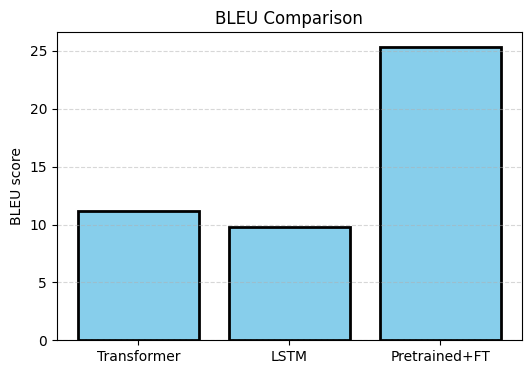

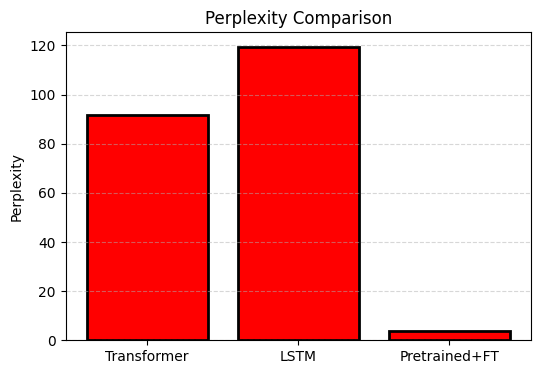

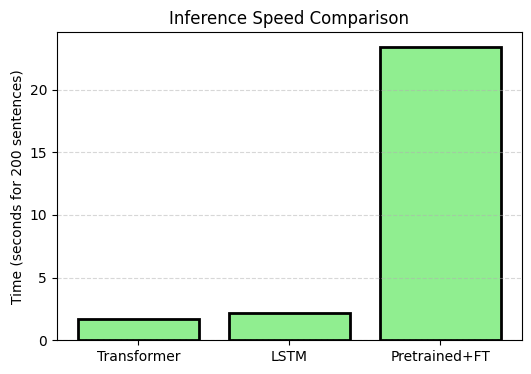

In [39]:
# Visualization – compare Transformer, LSTM, and Pretrained+FT

models = ["Transformer", "LSTM", "Pretrained+FT"]

# 1) BLEU scores
bleu_values = [bleu_score, lstm_bleu, mt_bleu]

plt.figure(figsize=(6, 4))
plt.bar(range(len(models)), bleu_values, color="skyblue", edgecolor='black', linewidth=2)
plt.xticks(range(len(models)), models)
plt.ylabel("BLEU score")
plt.title("BLEU Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig('bleu_comparison.png', dpi=300)
plt.show()

# 3) Perplexity (lower is better)
ppl_values = [test_ppl, lstm_test_ppl, mt_test_ppl]

plt.figure(figsize=(6, 4))
plt.bar(range(len(models)), ppl_values, color="red", edgecolor='black', linewidth=2)
plt.xticks(range(len(models)), models)
plt.ylabel("Perplexity")
plt.title("Perplexity Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig('perplexity_comparison.png', dpi=300)
plt.show()

# 4) Inference time for 200 sentences (seconds)
time_values = [inf_time, lstm_inf_time, mt_inf_time]

plt.figure(figsize=(6, 4))
plt.bar(range(len(models)), time_values, color="lightgreen", edgecolor='black', linewidth=2)
plt.xticks(range(len(models)), models)
plt.ylabel("Time (seconds for 200 sentences)")
plt.title("Inference Speed Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig('inferencetime_comparison.png', dpi=300)
plt.show()

In [31]:
# Simple text table of all metrics

print("=== Model Comparison Summary ===")
print(f"{'Model':<15} {'BLEU':>8} {'ROUGE-L':>10} {'PPL':>10} {'Inf Time(s)':>12}")
print("-" * 60)
print(f"{'Transformer':<15} {bleu_score:8.2f} {rouge_l:10.4f} {test_ppl:10.2f} {inf_time:12.2f}")
print(f"{'LSTM':<15} {lstm_bleu:8.2f} {lstm_rouge:10.4f} {lstm_test_ppl:10.2f} {lstm_inf_time:12.2f}")
print(f"{'Pretrained+FT':<15} {mt_bleu:8.2f} {mt_rouge:10.4f} {mt_test_ppl:10.2f} {mt_inf_time:12.2f}")

=== Model Comparison Summary ===
Model               BLEU    ROUGE-L        PPL  Inf Time(s)
------------------------------------------------------------
Transformer        11.14     0.0000      91.85         1.71
LSTM                9.75     0.0000     119.39         2.15
Pretrained+FT      25.34     0.0000       3.71        23.40
